
Sube EXACTAMENTE 3 fotos (una cara por foto)


Saving 4.png to 4 (1).png
Saving 2.webp to 2 (2).webp
Saving 1.jpg to 1 (2).jpg

Detección con 'retinaface' y obtención de caras ALINEADAS

Visualización: Original, Detección (bbox) y Cara alineada


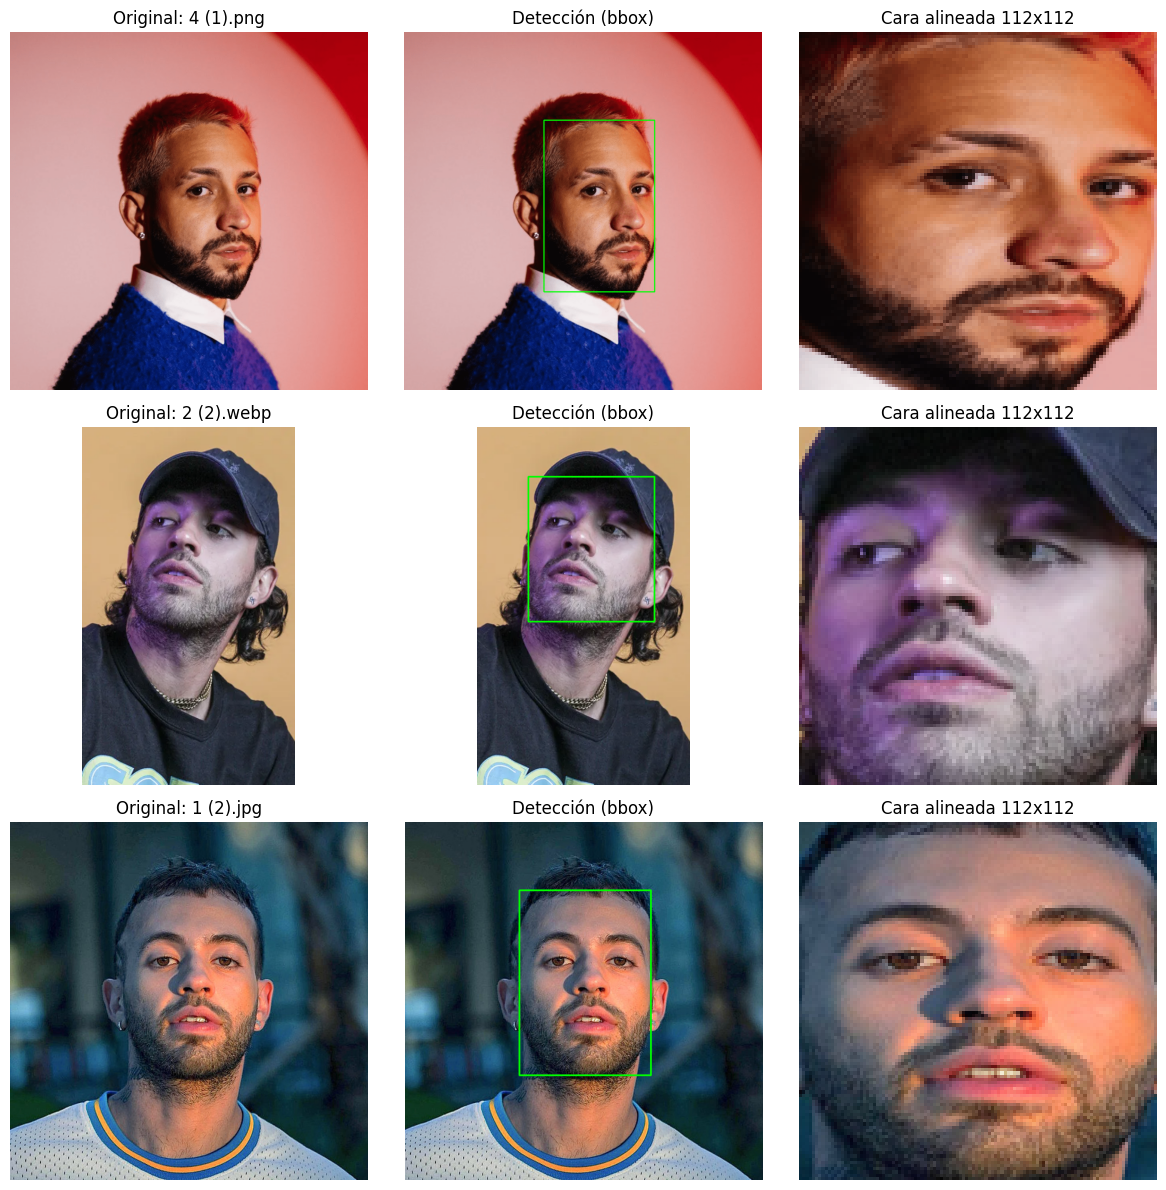


Embeddings con ArcFace | TTA flip=True
- Procesando embedding de: 4 (1).png
  Dim: (512,), primeros valores: [-0.02431758  0.06470434 -0.01511013 -0.05274301 -0.00610683]
- Procesando embedding de: 2 (2).webp
  Dim: (512,), primeros valores: [-0.02426971  0.06474053 -0.01509395 -0.05280709 -0.00614972]
- Procesando embedding de: 1 (2).jpg
  Dim: (512,), primeros valores: [-0.02433828  0.06489924 -0.01506838 -0.05274499 -0.00623532]

Cálculo de matrices (3x3) de Euclídea y Similitud Coseno
Matriz de distancias Euclidianas:
 [[0.         0.00327328 0.0034697 ]
 [0.00327328 0.         0.00263225]
 [0.0034697  0.00263225 0.        ]]

Matriz de similitud por Coseno:
 [[1.         0.9999946  0.99999404]
 [0.9999946  1.         0.99999666]
 [0.99999404 0.99999666 1.0000001 ]]


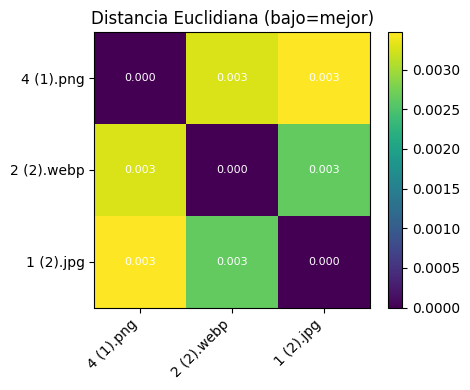

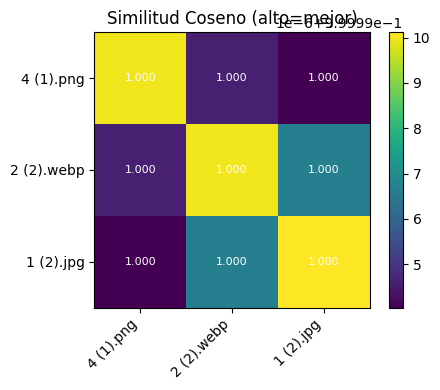


Comparaciones por pares
  4 (1).png ↔ 2 (2).webp | Euclídea=0.0033 | Coseno=1.0000
  4 (1).png ↔ 1 (2).jpg | Euclídea=0.0035 | Coseno=1.0000
  2 (2).webp ↔ 1 (2).jpg | Euclídea=0.0026 | Coseno=1.0000

Resultado
✅ Por Euclídea (menor es mejor): '2 (2).webp' y '1 (2).jpg' (d=0.0026)
✅ Por Coseno  (mayor es mejor) : '2 (2).webp' y '1 (2).jpg' (sim=1.0000)

Consulta: tomar la PRIMERA imagen como referencia
🔎 Euclídea: '4 (1).png' se parece más a '2 (2).webp' (d01=0.0033 vs d02=0.0035)
🔎 Coseno  : '4 (1).png' se parece más a '2 (2).webp' (s01=1.0000 vs s02=1.0000)

Cómo interpretar los resultados
• Visualizamos qué CARA recortó/alineó el detector (retinaface) y la usamos para el embedding.
• Euclídea: cuanto más BAJA, más parecidos.
• Coseno: cuanto más ALTA (≈1), más parecidos.
• Con embeddings normalizados L2, Coseno suele ser muy estable.
• Si hay fotos con pose/luz muy diferentes, TTA por flip ayuda un poco; prueba también con otras imágenes.


In [3]:
# ============================================================
# COLAB · Comparación de 3 rostros con DeepFace (ArcFace)
# + Visualización de detección y caras alineadas
# + Euclídea y Coseno + Heatmaps
# David Santiago Perez Gomez
# ============================================================

# 0) Instalación de DeepFace (si no está instalado)
try:
    from deepface import DeepFace
except Exception:
    !pip -q install deepface >/dev/null
from deepface import DeepFace

import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from typing import List, Tuple

# ---------- Parámetros ----------
MODEL_NAME      = "ArcFace"      # ArcFace para embeddings robustos
DETECTOR        = "retinaface"   # Detector facial (preciso y moderno)
USE_FLIP_TTA    = True           # Promedia embedding con imagen espejada
TARGET_SIZE     = (112, 112)     # Tamaño de la cara alineada (DeepFace ya alinea)
SHOW_ALIGNED    = True           # Mostrar caras alineadas/normalizadas
CMAP            = "viridis"      # Mapa de color para heatmaps

# ---------- Utilidades ----------
def paso(msg: str):
    """Separador bonito para etapas."""
    print("\n" + "="*70 + f"\n{msg}\n" + "="*70)

def l2_normalizar(v: np.ndarray) -> np.ndarray:
    """Normaliza un vector a norma L2 = 1 para comparar mejor."""
    n = np.linalg.norm(v)
    return v if n == 0 else (v / n)

def euclidiana(u: np.ndarray, v: np.ndarray) -> float:
    """d(u,v) = ||u - v||2."""
    return float(np.linalg.norm(u - v))

def cosine_similarity(u: np.ndarray, v: np.ndarray) -> float:
    """cos(u,v) = (u·v)/(||u|| ||v||). Con L2 previo, es muy estable."""
    denom = (np.linalg.norm(u) * np.linalg.norm(v))
    if denom == 0:
        return 0.0
    return float(np.dot(u, v) / denom)

def draw_bbox_on_image(bgr: np.ndarray, area: dict, color=(0,255,0), thickness=2) -> np.ndarray:
    """Dibuja un rectángulo usando 'facial_area' de DeepFace."""
    x, y, w, h = area.get('x',0), area.get('y',0), area.get('w',0), area.get('h',0)
    out = bgr.copy()
    cv2.rectangle(out, (x,y), (x+w, y+h), color, thickness)
    return out

def extract_best_face(img_path) -> Tuple[np.ndarray, dict, np.ndarray]:
    """
    Usa DeepFace.extract_faces para obtener caras alineadas.
    - Devuelve la cara alineada (RGB float32 0..1), el área facial (x,y,w,h) y el original BGR con bbox.
    - Si hay múltiples rostros, toma el más grande.
    """
    # cargamos BGR para dibujar luego
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise ValueError(f"No se pudo leer la imagen: {img_path}")
    # extraer caras alineadas
    faces = DeepFace.extract_faces(
        img_path=bgr,              # ¡podemos pasar array!
        detector_backend=DETECTOR,
        enforce_detection=True,
        align=True
    )
    if len(faces) == 0:
        raise RuntimeError(f"No se detectó rostro en: {img_path}")

    # elegir la más grande por área
    def area_ff(f):
        a = f.get("facial_area", {})
        return a.get("w",0)*a.get("h",0)
    best = max(faces, key=area_ff)

    face_rgb = best["face"]        # numpy RGB float32 [0..1], ya alineada
    facial_area = best["facial_area"]
    # dibujar bbox en original
    bgr_with = draw_bbox_on_image(bgr, facial_area)
    return face_rgb, facial_area, bgr_with

def embed_arcface_from_aligned_rgb(face_rgb: np.ndarray, flip_tta: bool = True) -> np.ndarray:
    """
    Obtiene embedding ArcFace desde una cara ya alineada (RGB float32 0..1).
    Aplica opcionalmente TTA con flip horizontal y promedia.
    Normaliza L2 al final.
    """
    # DeepFace.represent acepta np.ndarray en RGB
    rep = DeepFace.represent(
        img_path=face_rgb,
        model_name=MODEL_NAME,
        detector_backend=DETECTOR,   # igual se ignora si ya pasamos la cara alineada
        enforce_detection=False      # ya detectamos/recortamos
    )
    vecs = [np.array(rep[0]["embedding"], dtype="float32")]

    if flip_tta:
        face_flip = cv2.flip((face_rgb*255).astype(np.uint8), 1).astype(np.float32)/255.0
        rep2 = DeepFace.represent(
            img_path=face_flip,
            model_name=MODEL_NAME,
            detector_backend=DETECTOR,
            enforce_detection=False
        )
        vecs.append(np.array(rep2[0]["embedding"], dtype="float32"))

    emb = np.mean(vecs, axis=0).astype("float32")
    emb = l2_normalizar(emb)
    return emb

def plot_grid_images(originals_bgr: List[np.ndarray], with_bbox_bgr: List[np.ndarray],
                     aligned_rgb: List[np.ndarray], titles: List[str]):
    """Muestra: original, original+bbox y cara alineada por cada imagen."""
    n = len(originals_bgr)
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        # original
        plt.subplot(n, 3, 3*i+1)
        plt.imshow(cv2.cvtColor(originals_bgr[i], cv2.COLOR_BGR2RGB))
        plt.title(f"Original: {titles[i]}")
        plt.axis('off')
        # con bbox
        plt.subplot(n, 3, 3*i+2)
        plt.imshow(cv2.cvtColor(with_bbox_bgr[i], cv2.COLOR_BGR2RGB))
        plt.title("Detección (bbox)")
        plt.axis('off')
        # cara alineada
        plt.subplot(n, 3, 3*i+3)
        plt.imshow(np.clip(aligned_rgb[i],0,1))
        plt.title(f"Cara alineada {aligned_rgb[i].shape[1]}x{aligned_rgb[i].shape[0]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def plot_matrix_heatmap(M: np.ndarray, labels: List[str], title: str, is_similarity: bool):
    """
    Dibuja un heatmap: si es distancia, valores bajos son mejores (fríos);
    si es similitud, valores altos son mejores (calientes).
    """
    plt.figure(figsize=(5,4))
    plt.imshow(M, cmap=CMAP)
    plt.colorbar()
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.yticks(range(len(labels)), labels)
    plt.title(title + (" (alto=mejor)" if is_similarity else " (bajo=mejor)"))
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, f"{M[i,j]:.3f}", ha='center', va='center', color='w', fontsize=8)
    plt.tight_layout()
    plt.show()

# ---------- 1) Subir imágenes ----------
paso("Sube EXACTAMENTE 3 fotos (una cara por foto)")
uploaded = files.upload()
imgs = list(uploaded.keys())
if len(imgs) != 3:
    raise ValueError(f"Se requieren 3 imágenes. Recibidas: {len(imgs)}")

# ---------- 2) Detección, visualización y caras alineadas ----------
paso(f"Detección con '{DETECTOR}' y obtención de caras ALINEADAS")
aligned_rgb_list, facial_areas, originals_bgr, with_bbox_bgr = [], [], [], []
for r in imgs:
    face_rgb, area, bgr_with = extract_best_face(r)
    # guardamos también el original BGR (para mostrarlo)
    orig_bgr = cv2.imread(r)
    originals_bgr.append(orig_bgr)
    with_bbox_bgr.append(bgr_with)
    facial_areas.append(area)
    # opcionalmente redimensionar la cara a TARGET_SIZE (DeepFace suele devolver ~224x224 o 112x112)
    face_resized = cv2.resize((face_rgb*255).astype(np.uint8), TARGET_SIZE, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    aligned_rgb_list.append(face_resized)

# Mostrar grid de originales, bbox y caras alineadas
paso("Visualización: Original, Detección (bbox) y Cara alineada")
plot_grid_images(originals_bgr, with_bbox_bgr, aligned_rgb_list, imgs)

# ---------- 3) Embeddings con ArcFace ----------
paso(f"Embeddings con {MODEL_NAME} | TTA flip={USE_FLIP_TTA}")
embs = []
for i, face_rgb in enumerate(aligned_rgb_list):
    print(f"- Procesando embedding de: {imgs[i]}")
    emb = embed_arcface_from_aligned_rgb(face_rgb, flip_tta=USE_FLIP_TTA)
    print(f"  Dim: {emb.shape}, primeros valores: {emb[:5]}")
    embs.append(emb)

# ---------- 4) Métricas: Euclídea (bajo=mejor) y Coseno (alto=mejor) ----------
paso("Cálculo de matrices (3x3) de Euclídea y Similitud Coseno")
n = len(embs)
D = np.zeros((n, n), dtype=np.float32)  # distancias euclidianas
S = np.zeros((n, n), dtype=np.float32)  # similitud coseno

for i in range(n):
    for j in range(n):
        D[i, j] = euclidiana(embs[i], embs[j])
        S[i, j] = cosine_similarity(embs[i], embs[j])

print("Matriz de distancias Euclidianas:\n", D)
print("\nMatriz de similitud por Coseno:\n", S)

# Heatmaps
plot_matrix_heatmap(D, imgs, "Distancia Euclidiana", is_similarity=False)
plot_matrix_heatmap(S, imgs, "Similitud Coseno",   is_similarity=True)

# ---------- 5) Recuento por pares (i<j) ----------
paso("Comparaciones por pares")
pares = []
for i in range(n):
    for j in range(i+1, n):
        print(f"  {imgs[i]} ↔ {imgs[j]} | Euclídea={D[i,j]:.4f} | Coseno={S[i,j]:.4f}")
        pares.append(((i,j), D[i,j], S[i,j]))

# Mejor par por Euclídea (mínimo) y por Coseno (máximo)
(mejor_i_e, mejor_j_e), dmin, _ = min(pares, key=lambda x: x[1])
(mejor_i_c, mejor_j_c), _, smax = max(pares, key=lambda x: x[2])

paso("Resultado")
print(f"✅ Por Euclídea (menor es mejor): '{imgs[mejor_i_e]}' y '{imgs[mejor_j_e]}' (d={dmin:.4f})")
print(f"✅ Por Coseno  (mayor es mejor) : '{imgs[mejor_i_c]}' y '{imgs[mejor_j_c]}' (sim={smax:.4f})")

# ---------- 6) Consulta: 1ra imagen como referencia ----------
paso("Consulta: tomar la PRIMERA imagen como referencia")
d01, d02 = D[0,1], D[0,2]
s01, s02 = S[0,1], S[0,2]
mas_parecida_e = imgs[1] if d01 < d02 else imgs[2]
mas_parecida_c = imgs[1] if s01 > s02 else imgs[2]
print(f"🔎 Euclídea: '{imgs[0]}' se parece más a '{mas_parecida_e}' (d01={d01:.4f} vs d02={d02:.4f})")
print(f"🔎 Coseno  : '{imgs[0]}' se parece más a '{mas_parecida_c}' (s01={s01:.4f} vs s02={s02:.4f})")

# ---------- 7) Notas de interpretación ----------
paso("Cómo interpretar los resultados")
print(
    "• Visualizamos qué CARA recortó/alineó el detector (retinaface) y la usamos para el embedding.\n"
    "• Euclídea: cuanto más BAJA, más parecidos.\n"
    "• Coseno: cuanto más ALTA (≈1), más parecidos.\n"
    "• Con embeddings normalizados L2, Coseno suele ser muy estable.\n"
    "• Si hay fotos con pose/luz muy diferentes, TTA por flip ayuda un poco; prueba también con otras imágenes."
)
